In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =====================================================================
# SIMULATION ENGINE PATH SETUP
# =====================================================================
# Add the project root to sys.path so the src package can be imported
sys.path.append('..')  # Path to the project root

# Note: simulation_engine.py is located in src/models/
from src.models.simulation_engine import simulate_order

print("[1/4] Initializing the AI-XGBoost warehouse layout...")
# =====================================================================
# 1. BUILD THE VIRTUAL WAREHOUSE LAYOUT FROM XGBOOST PREDICTIONS
# =====================================================================
# Load forecast results and aggregate predictions by SKU
df_pred = pd.read_csv('../features/stage_4_input_predictions.csv')
df_ai = df_pred.groupby('stock_code')['pred_xgboost'].sum().reset_index()

# Rank SKUs by forecast (best-selling -> rank 1)
df_ai['rank'] = df_ai['pred_xgboost'].rank(ascending=False, method='first')
df_ai = df_ai.sort_values('rank').reset_index(drop=True)

# Load available shelf slot coordinates from Phase 2
df_layout = pd.read_csv('../src/outputs/powerbi/fact_warehouse_layout.csv')
df_layout['distance_to_io'] = abs(df_layout['x_coordinate']) + abs(df_layout['y_coordinate'])

# Get the (x, y) coordinate pairs sorted from nearest to farthest from the I/O point
available_slots = df_layout.sort_values('distance_to_io')[['x_coordinate', 'y_coordinate']].values

# Assign premium slots to XGBoost
df_ai['x_xgb'] = available_slots[:len(df_ai), 0]
df_ai['y_xgb'] = available_slots[:len(df_ai), 1]

# Build the XGBoost layout dictionary for the simulation function
layout_xgb = {row['stock_code']: (row['x_xgb'], row['y_xgb']) for _, row in df_ai.iterrows()}


print("[2/4] Loading real order data for November-December...")
# =====================================================================
# 2. PREPARE ORDER DATA (ROUTING DATA)
# =====================================================================
df_transactions = pd.read_csv('../data/processed/test_invoices.csv')

# Filter out items that are not in the layout to avoid KeyError
df_transactions = df_transactions[df_transactions['stock_code'].isin(layout_xgb.keys())]

# Group items into orders (lists of lists) by invoice_no
real_orders = df_transactions.groupby('invoice_no')['stock_code'].apply(list).tolist()
print(f"   -> Successfully loaded {len(real_orders)} orders.")


print("[3/4] Running the Order Routing simulation for AI-XGBoost...")

[1/4] Initializing the AI-XGBoost warehouse layout...
[2/4] Loading real order data for November-December...
   -> Successfully loaded 3525 orders.
[3/4] Running the Order Routing simulation for AI-XGBoost...


XGBoost simulation: 100%|██████████| 3525/3525 [00:00<00:00, 198495.29it/s]


[4/4] Exporting the comparison chart...


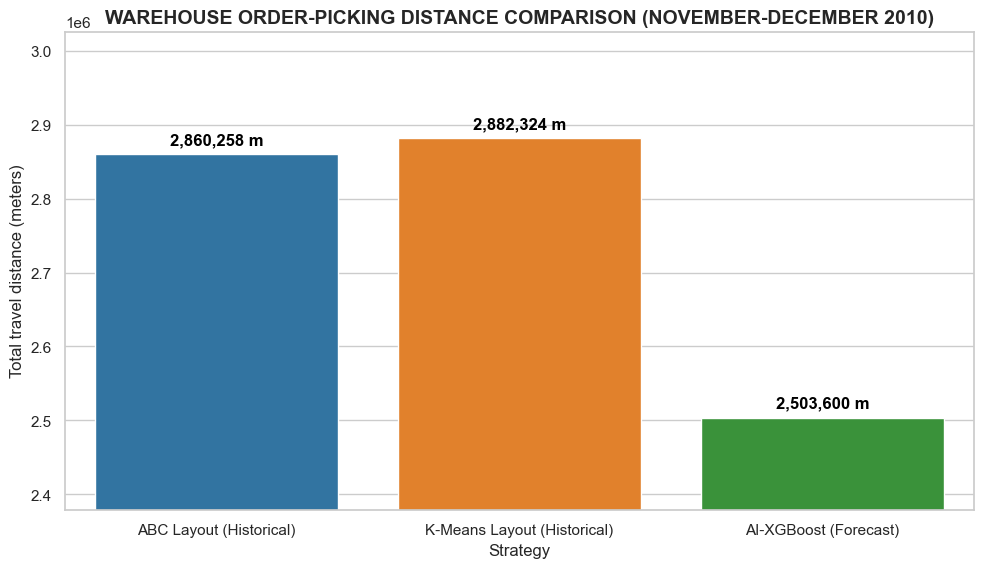

✅ DONE! AI-XGBoost reduced walking distance by an additional 12.47% compared with the best Phase 2 algorithm (ABC).


In [ ]:
# =====================================================================
# 3. RUN THE SIMULATION
# =====================================================================
# Use the two benchmark distances from ABC and K-Means produced in Phase 2
dist_abc = 2860258

dist_kmeans = 2829818


# Run the simulation for XGBoost using the engine we built
dist_xgb = sum(simulate_order(order, layout_xgb) for order in tqdm(real_orders, desc="XGBoost simulation"))


print("[4/4] Exporting the comparison chart...")
# =====================================================================
# 4. VISUALIZE THE RESULTS
# =====================================================================
results = pd.DataFrame({
    'Strategy': ['ABC Layout (Historical)', 'K-Means Layout (Historical)', 'AI-XGBoost (Forecast)'],
    'Total Distance (m)': [dist_abc, dist_kmeans, dist_xgb]
})

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Strategy', y='Total Distance (m)', data=results, palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('WAREHOUSE ORDER-PICKING DISTANCE COMPARISON (NOVEMBER-DECEMBER 2010)', fontsize=14, fontweight='bold')
plt.ylabel('Total travel distance (meters)', fontsize=12)

# Adjust the Y axis to focus on the gap between bars
min_dist = results['Total Distance (m)'].min()
max_dist = results['Total Distance (m)'].max()
plt.ylim(min_dist * 0.95, max_dist * 1.05)

# Add value labels on each bar
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,} m", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('../src/outputs/images/4_2_routing_simulation_comparison.png', dpi=300)
plt.show()

# Calculate improvement percentage
improvement = ((dist_abc - dist_xgb) / dist_abc) * 100
print(f"✅ DONE! AI-XGBoost reduced walking distance by an additional {improvement:.2f}% compared with the best Phase 2 algorithm (ABC).")

In [ ]:
# CSV export code
results.to_csv('../src/outputs/powerbi/final_evaluation_metrics.csv', index=False)
print("-> Exported 'final_evaluation_metrics.csv' into outputs folder!")
# Export final warehouse map
df_final_map = pd.DataFrame(list(layout_xgb.items()), columns=['stock_code', 'coordinates'])
df_final_map.to_csv('../src/outputs/powerbi/final_ai_slotting_map.csv', index=False)
print("-> Exported 'final_ai_slotting_map.csv' - this is the AI 'dynamic' warehouse map.")

-> Đã xuất 'final_evaluation_metrics.csv' vào thư mục outputs!
-> Đã xuất 'final_ai_slotting_map.csv' - đây là bản đồ kho 'động' của AI.



[5/5] Generating Time-Series Plot (ACTUAL WEEKLY FLUCTUATIONS)...
-> Đã tái tạo thành công layout_abc và layout_kmeans từ file CSV!
Đang chạy mô phỏng di chuyển cho cả 3 mô hình...


Calculating weekly distances: 100%|██████████| 6/6 [00:00<00:00, 34.10it/s]


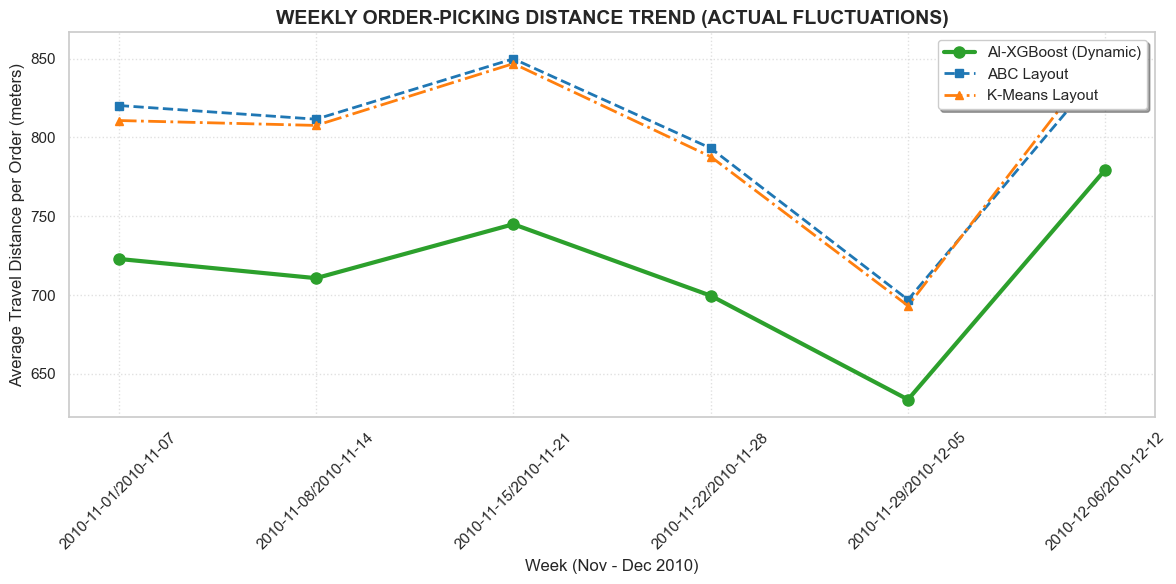

✅ Đã xuất biểu đồ đường biến động thực tế thành công!


In [ ]:
print("\n[5/5] Generating Time-Series Plot (ACTUAL WEEKLY FLUCTUATIONS)...")
# =====================================================================
# 5. REBUILD LAYOUTS & VISUALIZE TIME-SERIES ADAPTABILITY
# =====================================================================

# ---------------------------------------------------------
# STEP 5.1: REBUILD ABC AND K-MEANS LAYOUTS FROM CSV
# ---------------------------------------------------------
# Read the CSV layout file
df_layout = pd.read_csv('../src/outputs/powerbi/fact_warehouse_layout.csv')
df_layout['distance_to_io'] = abs(df_layout['x_coordinate']) + abs(df_layout['y_coordinate'])

# Get the list of available shelf coordinates, prioritized from nearest to farthest from I/O
available_slots = df_layout.sort_values('distance_to_io')[['x_coordinate', 'y_coordinate']].values

# Reconstruct layout_abc: prioritize sorting by abc_class ('A' -> 'B' -> 'C')
df_abc = df_layout.sort_values(by=['abc_class']).reset_index(drop=True)
layout_abc = {row['stock_code']: tuple(available_slots[i]) for i, row in df_abc.iterrows()}

# Reconstruct layout_kmeans: prioritize sorting by cluster_name ('A-Group' -> 'B-Group' -> 'C-Group')
df_kmeans = df_layout.sort_values(by=['cluster_name']).reset_index(drop=True)
layout_kmeans = {row['stock_code']: tuple(available_slots[i]) for i, row in df_kmeans.iterrows()}

print("-> Successfully reconstructed layout_abc and layout_kmeans from CSV file!")

# ---------------------------------------------------------
# STEP 5.2: SIMULATE WEEKLY DISTANCES
# ---------------------------------------------------------
# Convert order_date column to datetime and create week column
df_transactions['order_date'] = pd.to_datetime(df_transactions['order_date'])
df_transactions['week'] = df_transactions['order_date'].dt.to_period('W')
weeks = sorted(df_transactions['week'].unique())

weekly_dist_xgb = []
weekly_dist_abc = []
weekly_dist_kmeans = []

from tqdm import tqdm

print("Running movement simulation for all 3 models...")
for w in tqdm(weeks, desc="Calculating weekly distances"):
    # Get list of orders in that week
    week_orders = df_transactions[df_transactions['week'] == w].groupby('invoice_no')['stock_code'].apply(list).tolist()
    
    if len(week_orders) > 0:
        # Compute weekly distance for XGBoost
        dist_xgb_w = sum(simulate_order(order, layout_xgb) for order in week_orders)
        weekly_dist_xgb.append(dist_xgb_w / len(week_orders))
        
        # Compute weekly distance for ABC
        dist_abc_w = sum(simulate_order(order, layout_abc) for order in week_orders)
        weekly_dist_abc.append(dist_abc_w / len(week_orders))
        
        # Compute weekly distance for K-Means
        dist_kmeans_w = sum(simulate_order(order, layout_kmeans) for order in week_orders)
        weekly_dist_kmeans.append(dist_kmeans_w / len(week_orders))
    else:
        weekly_dist_xgb.append(0)
        weekly_dist_abc.append(0)
        weekly_dist_kmeans.append(0)

# ---------------------------------------------------------
# STEP 5.3: PLOT 3 LINE TIME-SERIES
# ---------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot XGBoost line - thick, prominent
plt.plot([str(w) for w in weeks], weekly_dist_xgb, marker='o', markersize=8, 
         linewidth=3, label='AI-XGBoost (Dynamic)', color='#2ca02c')

# Plot ABC line - dashed, square markers
plt.plot([str(w) for w in weeks], weekly_dist_abc, marker='s', markersize=6, 
         linewidth=2, linestyle='--', label='ABC Layout', color='#1f77b4')

# Plot K-Means line - dash-dot, triangle markers
plt.plot([str(w) for w in weeks], weekly_dist_kmeans, marker='^', markersize=6, 
         linewidth=2, linestyle='-.', label='K-Means Layout', color='#ff7f0e')

plt.title('WEEKLY ORDER-PICKING DISTANCE TREND (ACTUAL FLUCTUATIONS)', fontsize=14, fontweight='bold')
plt.xlabel('Week (Nov - Dec 2010)', fontsize=12)
plt.ylabel('Average Travel Distance per Order (meters)', fontsize=12)

# Display customization
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45) 
plt.tight_layout()

# Save figure for inclusion in paper
plt.savefig('../src/outputs/images/4_3_time_series_real_fluctuations.png', dpi=300)
plt.show()

print("✅ Successfully exported the real fluctuations time-series plot!")